In [1]:
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

In [2]:
candidates = [
    Path.cwd() / 'data' / 'datasets' / 'cucumber_v1',
    Path.cwd() / 'vegvision-yolo' / 'data' / 'datasets' / 'cucumber_v1',
    Path(r'c:\Users\User\Desktop\vegvision-yolo\data\datasets\cucumber_v1'),
]

DATASET_PATH = next((p for p in candidates if p.exists()), candidates[0])
PROJECT_ROOT = DATASET_PATH.parents[2] if len(DATASET_PATH.parents) >= 3 else Path.cwd()
PLOTS_PATH = PROJECT_ROOT / 'data' / 'output' / 'cucumber_v1'
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

print('Using dataset path:', DATASET_PATH.resolve())
print('Using output path:', PLOTS_PATH.resolve())

if not DATASET_PATH.exists():
    print('Warning: dataset folder not found. Checked:')
    for p in candidates:
        print(' -', p)

data_yaml_path = DATASET_PATH / 'data.yaml'
dataset_info = {}
if data_yaml_path.exists():
    with open(data_yaml_path, 'r', encoding='utf8') as f:
        dataset_info = yaml.safe_load(f) or {}
    print('Loaded', data_yaml_path.resolve())
else:
    print('Warning: data.yaml not found at', data_yaml_path)

names = dataset_info.get('names') or dataset_info.get('label_names') or dataset_info.get('classes')
if isinstance(names, dict):
    class_map = {int(k): v for k, v in names.items()}
elif isinstance(names, list):
    class_map = {i: n for i, n in enumerate(names)}
else:
    class_map = {}

print('Dataset absolute path:', DATASET_PATH.resolve())
print('Detected classes (id -> name):')
print(class_map)
print('Number of classes:', len(class_map))

yaml_splits = []
for k in ['train', 'val', 'valid', 'test']:
    if k in dataset_info:
        yaml_splits.append(k)

fs_splits = [p.name for p in DATASET_PATH.iterdir() if p.is_dir()] if DATASET_PATH.exists() else []
print('Splits from data.yaml:', yaml_splits)
print('Splits found on disk:', fs_splits)

Using dataset path: C:\Users\User\Desktop\vegvision-yolo\data\datasets\cucumber_v1
Using output path: C:\Users\User\Desktop\vegvision-yolo\data\output\cucumber_v1
Loaded C:\Users\User\Desktop\vegvision-yolo\data\datasets\cucumber_v1\data.yaml
Dataset absolute path: C:\Users\User\Desktop\vegvision-yolo\data\datasets\cucumber_v1
Detected classes (id -> name):
{0: 'angular_lesions', 1: 'anthracnose'}
Number of classes: 2
Splits from data.yaml: ['train', 'val', 'test']
Splits found on disk: ['test', 'train', 'valid']


# Структура датасета

In [3]:
def count_files(folder: Path, patterns=('*.jpg', '*.png', '*.jpeg', '*.bmp')) -> int:
    if not folder.exists():
        return 0
    return sum(len(list(folder.glob(pat))) for pat in patterns)

splits = ['train', 'valid', 'test']
rows = []
for s in splits:
    images_dir = DATASET_PATH / s / 'images'
    labels_dir = DATASET_PATH / s / 'labels'
    num_images = count_files(images_dir)
    num_label_files = len(list(labels_dir.glob('*.txt'))) if labels_dir.exists() else 0
    empty_labels = 0
    images_without_labels = 0
    if images_dir.exists():
        for img_path in images_dir.glob('*'):
            if img_path.is_file():
                label_path = labels_dir / (img_path.stem + '.txt')
                if not label_path.exists():
                    images_without_labels += 1
    if labels_dir.exists():
        for lf in labels_dir.glob('*.txt'):
            try:
                if lf.stat().st_size == 0:
                    empty_labels += 1
                else:
                    with open(lf, 'r', encoding='utf8') as fh:
                        lines = [line for line in fh.read().splitlines() if line.strip()]
                        if not lines:
                            empty_labels += 1
            except Exception:
                pass
    rows.append({
        'split': s,
        'num_images': num_images,
        'num_labels': num_label_files,
        'empty_labels': empty_labels,
        'images_without_labels': images_without_labels,
    })

split_stats_df = pd.DataFrame(rows)
display(split_stats_df)
split_stats_df.to_csv(PLOTS_PATH / 'split_stats.csv', index=False)
print('Saved split stats to', (PLOTS_PATH / 'split_stats.csv').resolve())

,split,num_images,num_labels,empty_labels,images_without_labels
0,train,5868,5868,2616,0
1,valid,651,651,287,0
2,test,653,653,295,0


Saved split stats to C:\Users\User\Desktop\vegvision-yolo\data\output\cucumber_v1\split_stats.csv


# Анализ классов и аннотаций

In [4]:
bbox_rows = []
invalid_rows = []
splits_present = [s for s in ['train','valid','test'] if (DATASET_PATH / s).exists()]
for s in splits_present:
    labels_dir = DATASET_PATH / s / 'labels'
    images_dir = DATASET_PATH / s / 'images'
    if not labels_dir.exists():
        continue
    for lf in labels_dir.glob('*.txt'):
        img_path = images_dir / (lf.stem + '.jpg')
        if not img_path.exists():
            for ext in ['.png', '.jpeg', '.bmp']:
                cand = images_dir / (lf.stem + ext)
                if cand.exists():
                    img_path = cand
                    break
        with open(lf, 'r', encoding='utf8', errors='ignore') as f:
            lines = [l.strip() for l in f.read().splitlines() if l.strip()]
        for i, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) < 5:
                invalid_rows.append({'file': str(lf), 'line_no': i, 'line': line, 'reason': 'wrong_num_fields'})
                continue
            try:
                class_id = int(float(parts[0]))
                x_c = float(parts[1])
                y_c = float(parts[2])
                w = float(parts[3])
                h = float(parts[4])
            except Exception as e:
                invalid_rows.append({'file': str(lf), 'line_no': i, 'line': line, 'reason': f'parse_error: {e}'})
                continue
            if class_id not in class_map:
                invalid_rows.append({'file': str(lf), 'line_no': i, 'line': line, 'reason': 'class_id_out_of_range'})
                class_name = class_map.get(class_id, 'UNKNOWN')
            else:
                class_name = class_map.get(class_id)
            coord_err = False
            for val in (x_c, y_c, w, h):
                if not (0.0 <= val <= 1.0):
                    coord_err = True
            if coord_err:
                invalid_rows.append({'file': str(lf), 'line_no': i, 'line': line, 'reason': 'coords_out_of_range'})
                continue
            area_rel = w * h
            bbox_rows.append({'split': s, 'image_path': str(img_path), 'class_id': class_id, 'class_name': class_name, 'width': w, 'height': h, 'area_rel': area_rel})

bboxes_df = pd.DataFrame(bbox_rows)
print('Total valid bboxes:', len(bboxes_df))
if not bboxes_df.empty:
    class_counts = bboxes_df['class_name'].value_counts().rename_axis('class_name').reset_index(name='count')
    display(class_counts)
    class_counts.to_csv(PLOTS_PATH / 'class_counts.csv', index=False)
    bboxes_df.to_csv(PLOTS_PATH / 'bboxes.csv', index=False)
    print('Saved class_counts.csv and bboxes.csv in', PLOTS_PATH.resolve())
else:
    print('No valid bboxes found.')

invalid_df = pd.DataFrame(invalid_rows)
print('Invalid annotation lines:', len(invalid_df))
if not invalid_df.empty:
    display(invalid_df.head(20))
    invalid_df.to_csv(PLOTS_PATH / 'invalid_annotations_report.csv', index=False)
    print('Saved invalid_annotations_report.csv')

Total valid bboxes: 12576


,class_name,count
0,angular_lesions,6394
1,anthracnose,6182


Saved class_counts.csv and bboxes.csv in C:\Users\User\Desktop\vegvision-yolo\data\output\cucumber_v1
Invalid annotation lines: 0


# Распределение размеров bounding box

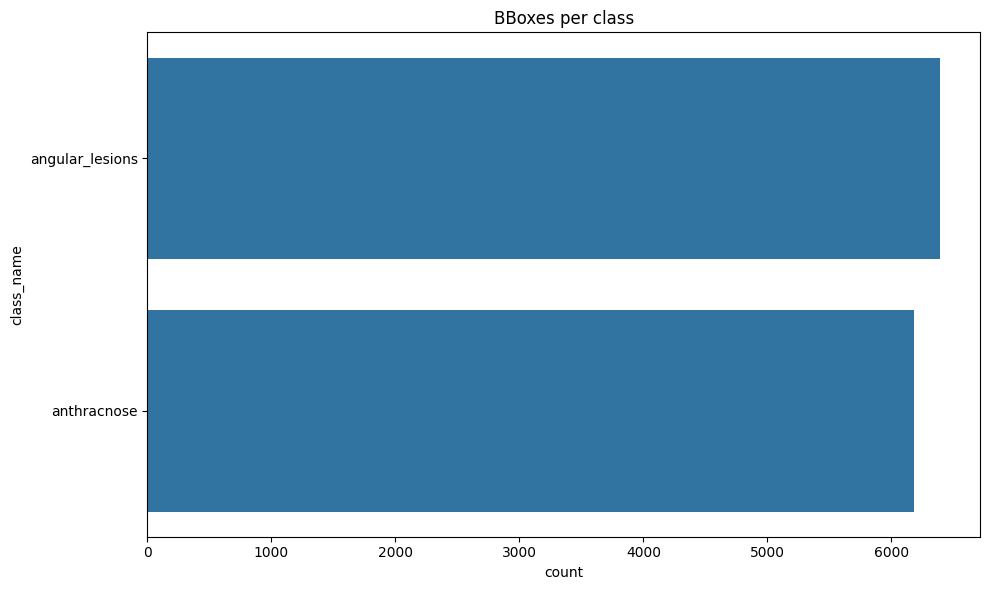

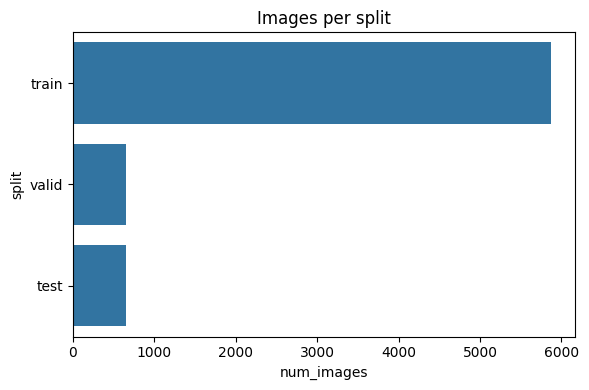

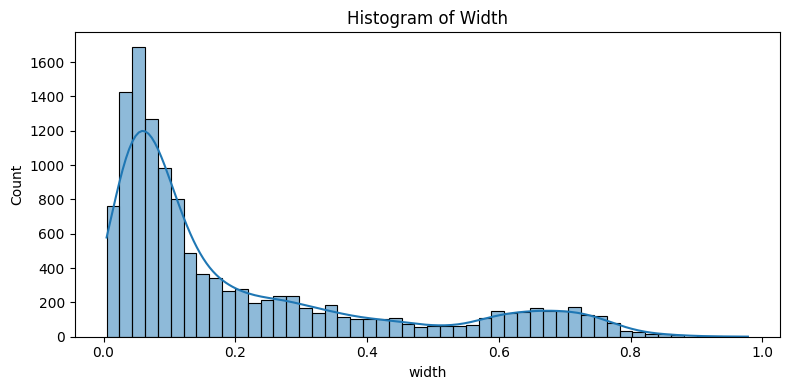

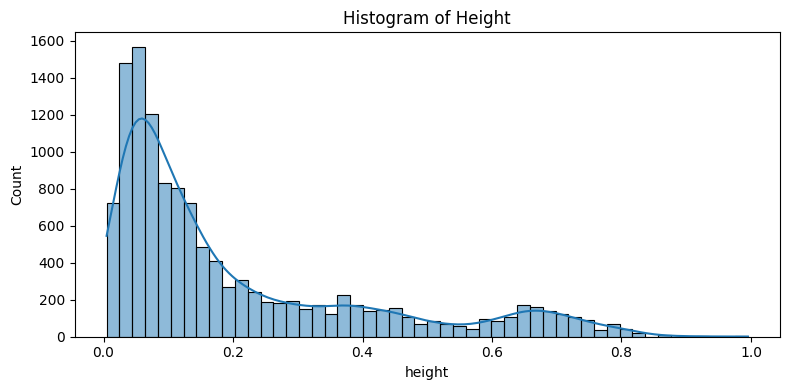

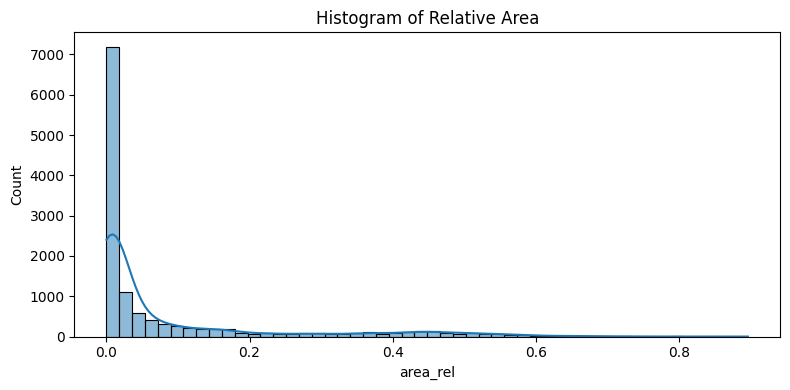

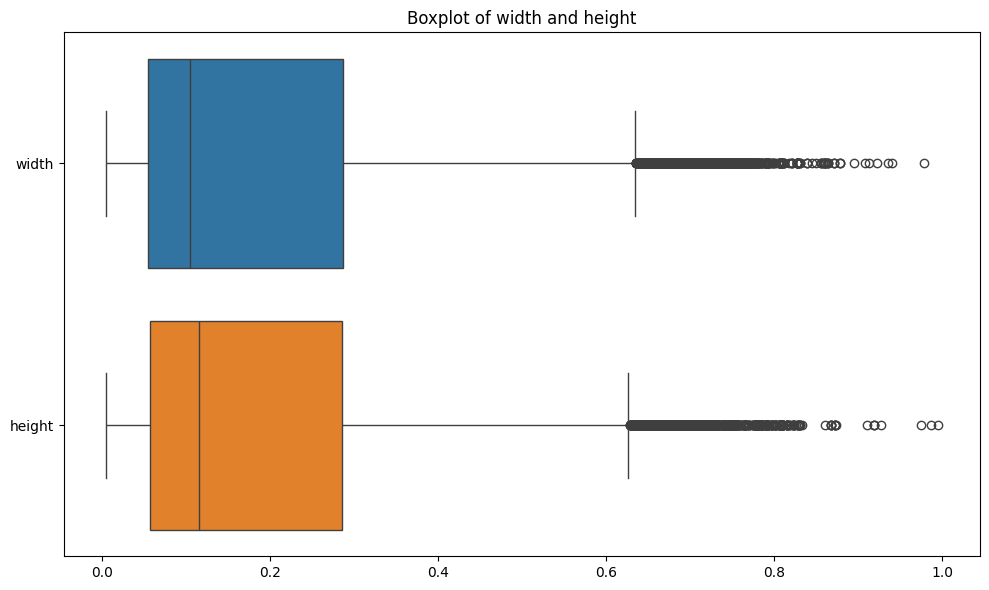

In [5]:
if not bboxes_df.empty:
    plt.figure(figsize=(10,6))
    sns.countplot(data=bboxes_df, y='class_name', order=bboxes_df['class_name'].value_counts().index)
    plt.title('BBoxes per class')
    plt.tight_layout()
    plt.savefig(PLOTS_PATH / 'bboxes_per_class.png', dpi=300)
    display(plt.gcf())
    plt.close()

    plt.figure(figsize=(6,4))
    sns.barplot(data=split_stats_df, x='num_images', y='split')
    plt.title('Images per split')
    plt.tight_layout()
    plt.savefig(PLOTS_PATH / 'images_per_split.png', dpi=300)
    display(plt.gcf())
    plt.close()

    for col, name in [('width','Width'), ('height','Height'), ('area_rel','Relative Area')]:
        plt.figure(figsize=(8,4))
        sns.histplot(bboxes_df[col], bins=50, kde=True)
        plt.title(f'Histogram of {name}')
        plt.tight_layout()
        fname = f'{col}_hist.png'
        plt.savefig(PLOTS_PATH / fname, dpi=300)
        display(plt.gcf())
        plt.close()

    plt.figure(figsize=(10,6))
    sns.boxplot(data=bboxes_df[['width','height']], orient='h')
    plt.title('Boxplot of width and height')
    plt.tight_layout()
    plt.savefig(PLOTS_PATH / 'boxplot_wh.png', dpi=300)
    display(plt.gcf())
    plt.close()
else:
    print('No bbox data to plot.')

# Визуальные примеры с аннотациями

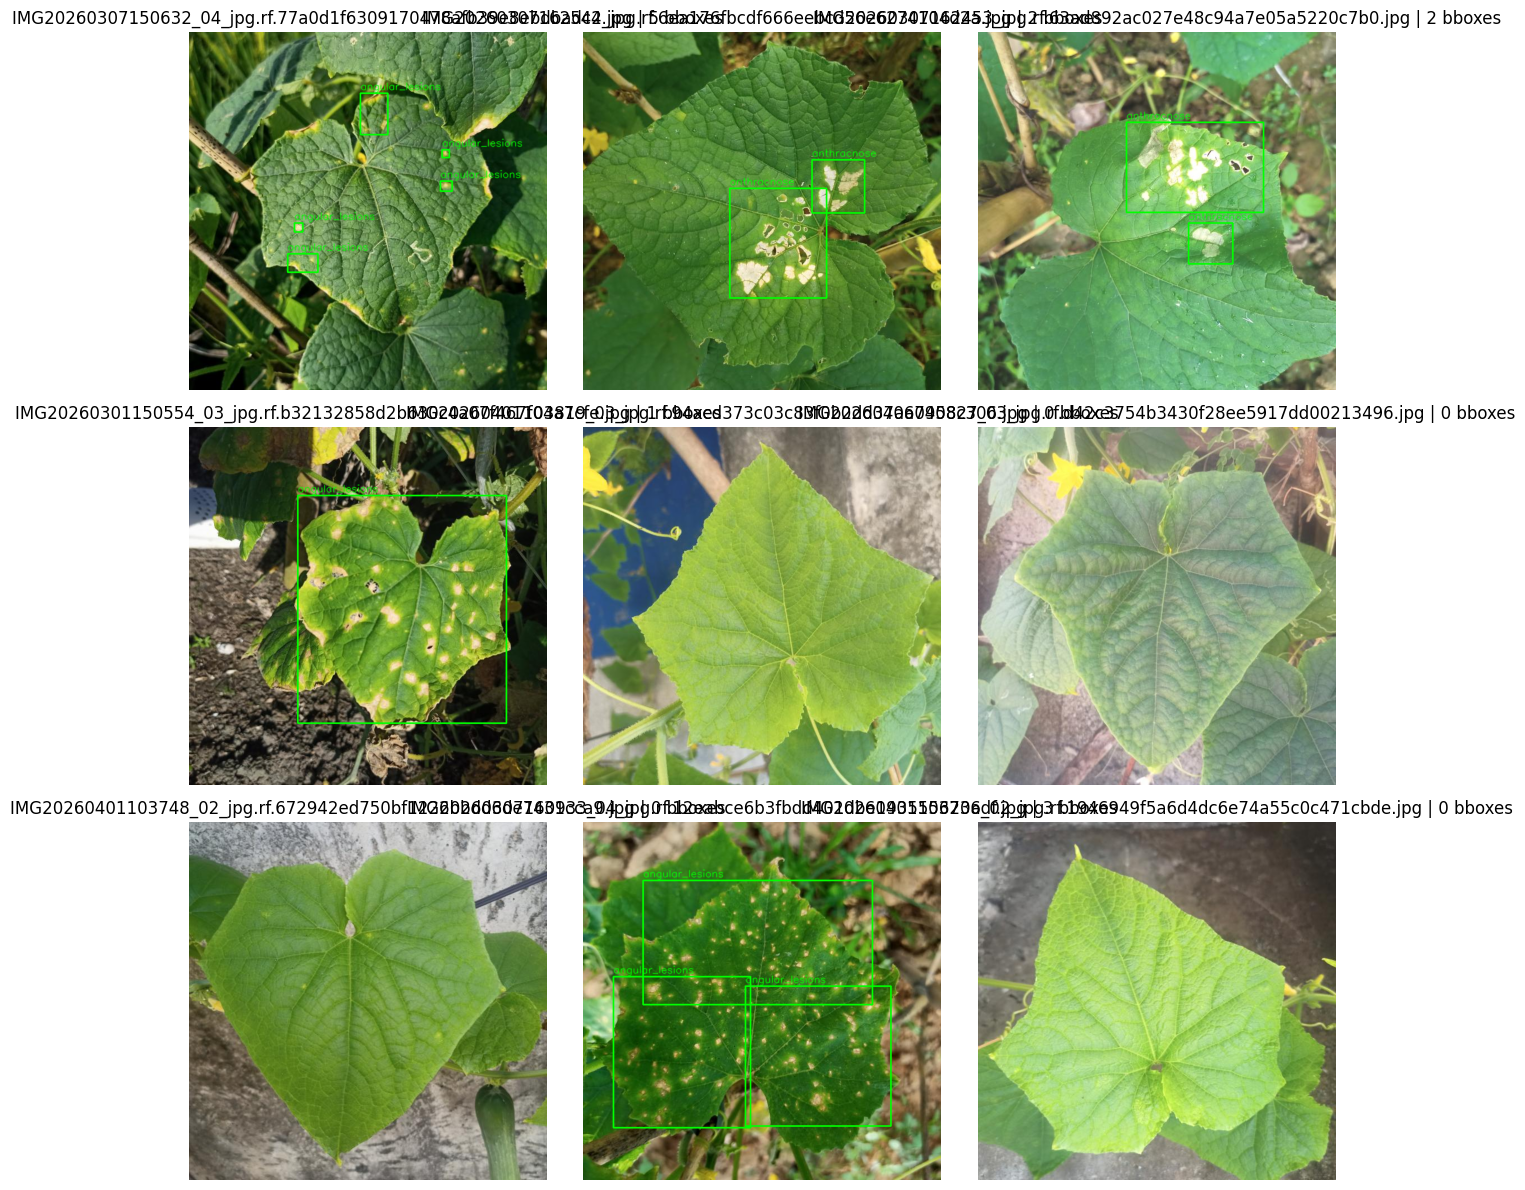

In [6]:
NUM_SAMPLES_TO_SHOW = 9

def draw_bboxes_on_image(img_path, labels):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    for l in labels:
        cls = l['class_id']
        x_c, y_c, bw, bh = l['x_c'], l['y_c'], l['w'], l['h']
        x1 = int((x_c - bw / 2) * w)
        y1 = int((y_c - bh / 2) * h)
        x2 = int((x_c + bw / 2) * w)
        y2 = int((y_c + bh / 2) * h)
        color = (0, 255, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label_txt = str(class_map.get(cls, cls))
        cv2.putText(img, label_txt, (x1, max(y1 - 6, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1, cv2.LINE_AA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

source_split = 'train' if (DATASET_PATH / 'train').exists() else (splits_present[0] if splits_present else None)
if source_split is None:
    print('No splits found for visualization.')
else:
    images_dir = DATASET_PATH / source_split / 'images'
    labels_dir = DATASET_PATH / source_split / 'labels'
    image_files = [p for p in images_dir.glob('*') if p.is_file()] if images_dir.exists() else []
    sample_files = random.sample(image_files, min(NUM_SAMPLES_TO_SHOW, len(image_files))) if image_files else []
    plt.figure(figsize=(12, 12))
    for i, img_p in enumerate(sample_files, start=1):
        labf = labels_dir / (img_p.stem + '.txt')
        labels = []
        if labf.exists():
            for line in open(labf, 'r', encoding='utf8', errors='ignore').read().splitlines():
                parts = line.split()
                if len(parts) >= 5:
                    labels.append({'class_id': int(float(parts[0])), 'x_c': float(parts[1]), 'y_c': float(parts[2]), 'w': float(parts[3]), 'h': float(parts[4])})
        img_drawn = draw_bboxes_on_image(img_p, labels)
        plt.subplot(3, 3, i)
        if img_drawn is None:
            plt.text(0.5, 0.5, 'Cannot load image', ha='center')
        else:
            plt.imshow(img_drawn)
        plt.axis('off')
        plt.title(f'{img_p.name} | {len(labels)} bboxes')
    plt.tight_layout()
    plt.savefig(PLOTS_PATH / 'sample_grid.png', dpi=300)
    display(plt.gcf())
    plt.close()

# Проверка потенциальных проблем

In [7]:
print('Total invalid annotation lines:', len(invalid_rows))
if len(invalid_rows) > 0:
    inv = pd.DataFrame(invalid_rows)
    display(inv.head(50))
    inv.to_csv(PLOTS_PATH / 'invalid_lines_summary.csv', index=False)
    print('Saved invalid_lines_summary.csv')
else:
    print('No invalid annotation lines found.')

Total invalid annotation lines: 0
No invalid annotation lines found.


# Сохранение итоговых CSV

In [8]:
split_stats_df.to_csv(PLOTS_PATH / 'split_stats.csv', index=False)
if 'class_counts' in locals():
    class_counts.to_csv(PLOTS_PATH / 'class_counts.csv', index=False)
if 'bboxes_df' in locals() and not bboxes_df.empty:
    bboxes_df.to_csv(PLOTS_PATH / 'bboxes_detailed.csv', index=False)
print('All CSVs saved to', PLOTS_PATH.resolve())

All CSVs saved to C:\Users\User\Desktop\vegvision-yolo\data\output\cucumber_v1


# Конфигурация очистки и remap

In [9]:
import shutil

OUTPUT_PATH = PROJECT_ROOT / 'data' / 'cleaned_datasets' / 'cuc_cleaned_datasets'
REMOVE_EMPTY_IMAGES = False

REMAP_BY_NAME = {}
for _, cls_name in class_map.items():
    cls_name_str = str(cls_name)
    low = cls_name_str.lower()
    if ('healthy' in low) or ('здоров' in low):
        REMAP_BY_NAME[cls_name_str] = 'healthy_cucumber'
    else:
        REMAP_BY_NAME[cls_name_str] = 'disease_cucumber'

print('Config created:')
print(f'  OUTPUT_PATH: {OUTPUT_PATH}')
print(f'  REMOVE_EMPTY_IMAGES: {REMOVE_EMPTY_IMAGES}')
print('  REMAP_BY_NAME:')
for k, v in REMAP_BY_NAME.items():
    print(f'    {k} -> {v}')

Config created:
  OUTPUT_PATH: c:\Users\User\Desktop\vegvision-yolo\data\cleaned_datasets\cuc_cleaned_datasets
  REMOVE_EMPTY_IMAGES: False
  REMAP_BY_NAME:
    angular_lesions -> disease_cucumber
    anthracnose -> disease_cucumber


In [10]:
class_name_to_id = {v: k for k, v in class_map.items()}
id_to_class_name = {k: v for k, v in class_map.items()}

print('Исходные классы (id -> name):')
for cid in sorted(id_to_class_name.keys()):
    print(f'  {cid}: {id_to_class_name[cid]}')

print('\nКлассы для remap в disease_cucumber:')
for name, action in REMAP_BY_NAME.items():
    if action == 'disease_cucumber' and name in class_name_to_id:
        print(f'  {class_name_to_id[name]} ({name}) -> disease_cucumber')

print('\nКлассы для remap в healthy_cucumber:')
for name, action in REMAP_BY_NAME.items():
    if action == 'healthy_cucumber' and name in class_name_to_id:
        print(f'  {class_name_to_id[name]} ({name}) -> healthy_cucumber')

print('\nИтоговые классы cleaned датасета:')
print('  0 -> disease_cucumber')
print('  1 -> healthy_cucumber')

Исходные классы (id -> name):
  0: angular_lesions
  1: anthracnose

Классы для remap в disease_cucumber:
  0 (angular_lesions) -> disease_cucumber
  1 (anthracnose) -> disease_cucumber

Классы для remap в healthy_cucumber:

Итоговые классы cleaned датасета:
  0 -> disease_cucumber
  1 -> healthy_cucumber


In [11]:
def prepare_output_path(output_path: Path):
    if output_path.exists():
        shutil.rmtree(output_path)
        print(f'Removed existing {output_path.resolve()}')

    for split in ['train', 'valid', 'test']:
        (output_path / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_path / split / 'labels').mkdir(parents=True, exist_ok=True)

    print(f'Created directory structure in {output_path.resolve()}')

prepare_output_path(OUTPUT_PATH)

Created directory structure in C:\Users\User\Desktop\vegvision-yolo\data\cleaned_datasets\cuc_cleaned_datasets


In [12]:
def process_split(split_name: str):
    src_images_dir = DATASET_PATH / split_name / 'images'
    src_labels_dir = DATASET_PATH / split_name / 'labels'

    if not src_images_dir.exists():
        print(f'Split {split_name} не найден')
        return 0, 0, 0

    dst_images_dir = OUTPUT_PATH / split_name / 'images'
    dst_labels_dir = OUTPUT_PATH / split_name / 'labels'
    dst_images_dir.mkdir(parents=True, exist_ok=True)
    dst_labels_dir.mkdir(parents=True, exist_ok=True)

    final_name_to_id = {'disease_cucumber': 0, 'healthy_cucumber': 1}
    split_prefix = {'train': 'cuc_train', 'valid': 'cuc_valid', 'test': 'cuc_test'}

    processed_images = 0
    processed_bboxes = 0
    skipped_images = 0
    warnings = []

    for img_file in src_images_dir.glob('*'):
        if not img_file.is_file():
            continue

        label_file = src_labels_dir / (img_file.stem + '.txt')
        new_lines = []

        if label_file.exists():
            with open(label_file, 'r', encoding='utf8', errors='ignore') as f:
                lines = [l.strip() for l in f.read().splitlines() if l.strip()]

            for line in lines:
                parts = line.split()
                if len(parts) < 5:
                    warnings.append(f'{img_file.name}: wrong format line')
                    continue

                try:
                    src_class_id = int(float(parts[0]))
                    x_c, y_c, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                except Exception as e:
                    warnings.append(f'{img_file.name}: parse error {e}')
                    continue

                src_class_name = id_to_class_name.get(src_class_id)
                if src_class_name is None:
                    warnings.append(f'{img_file.name}: unknown class_id {src_class_id}')
                    continue

                action = REMAP_BY_NAME.get(src_class_name, 'disease_cucumber')
                new_class_id = final_name_to_id.get(action, 0)
                new_lines.append(f'{new_class_id} {x_c} {y_c} {w} {h}')
                processed_bboxes += 1

        should_save = False
        if new_lines:
            should_save = True
        elif not label_file.exists():
            should_save = True
        elif REMOVE_EMPTY_IMAGES is False:
            should_save = True

        if should_save:
            import shutil as sh
            prefix = split_prefix.get(split_name, split_name)
            new_stem = f'{prefix}_{processed_images:06d}'
            dst_img_path = dst_images_dir / f'{new_stem}{img_file.suffix.lower()}'
            dst_label_path = dst_labels_dir / f'{new_stem}.txt'

            try:
                sh.copy2(img_file, dst_img_path)
            except Exception as e:
                warnings.append(f'Failed copy {img_file} -> {dst_img_path}: {e}')
                continue

            try:
                with open(dst_label_path, 'w', encoding='utf8') as f:
                    if new_lines:
                        f.write('\n'.join(new_lines))
                        f.write('\n')
            except Exception as e:
                warnings.append(f'Failed write label {dst_label_path}: {e}')
                try:
                    dst_img_path.unlink()
                except Exception:
                    pass
                continue

            processed_images += 1
        else:
            skipped_images += 1

    if warnings:
        print(f'Split {split_name} warnings (showing up to 5):')
        for w in warnings[:5]:
            print(' -', w)

    print(f'Split {split_name}: {processed_images} images, {processed_bboxes} bboxes, skipped {skipped_images}')
    return processed_images, processed_bboxes, skipped_images

splits_to_process = [s for s in ['train', 'valid', 'test'] if (DATASET_PATH / s).exists()]
total_images = 0
total_bboxes = 0

for split in splits_to_process:
    n_img, n_bbox, n_skip = process_split(split)
    total_images += n_img
    total_bboxes += n_bbox

print(f'\nTotal: {total_images} images, {total_bboxes} bboxes')

Split train: 5868 images, 10316 bboxes, skipped 0
Split valid: 651 images, 1131 bboxes, skipped 0
Split valid: 651 images, 1131 bboxes, skipped 0
Split test: 653 images, 1129 bboxes, skipped 0

Total: 7172 images, 12576 bboxes
Split test: 653 images, 1129 bboxes, skipped 0

Total: 7172 images, 12576 bboxes


In [13]:
new_yaml_content = """path: .
train: train/images
val: valid/images
test: test/images
nc: 2
names:
  0: disease_cucumber
  1: healthy_cucumber
"""

new_yaml_path = OUTPUT_PATH / 'data.yaml'
with open(new_yaml_path, 'w', encoding='utf8') as f:
    f.write(new_yaml_content)

print(f'Created {new_yaml_path.resolve()}')

Created C:\Users\User\Desktop\vegvision-yolo\data\cleaned_datasets\cuc_cleaned_datasets\data.yaml


# Проверка результата cleaned датасета

In [14]:
def count_cleaned_dataset(output_path: Path):
    splits = ['train', 'valid', 'test']
    rows = []
    class_counts = {0: 0, 1: 0}
    class_id_to_name = {0: 'disease_cucumber', 1: 'healthy_cucumber'}

    for s in splits:
        images_dir = output_path / s / 'images'
        labels_dir = output_path / s / 'labels'

        if not images_dir.exists():
            continue

        num_images = len(list(images_dir.glob('*')))
        num_labels = len(list(labels_dir.glob('*.txt'))) if labels_dir.exists() else 0

        empty_labels = 0
        images_without_labels = 0
        total_bboxes = 0

        for img_path in images_dir.glob('*'):
            if img_path.is_file():
                label_path = labels_dir / (img_path.stem + '.txt')
                if not label_path.exists():
                    images_without_labels += 1

        if labels_dir.exists():
            for lf in labels_dir.glob('*.txt'):
                try:
                    with open(lf, 'r', encoding='utf8') as fh:
                        lines = [l for l in fh.read().splitlines() if l.strip()]
                        if len(lines) == 0:
                            empty_labels += 1
                        else:
                            total_bboxes += len(lines)
                            for line in lines:
                                parts = line.split()
                                if len(parts) >= 5:
                                    class_id = int(float(parts[0]))
                                    if class_id in class_counts:
                                        class_counts[class_id] += 1
                except Exception:
                    pass

        rows.append({
            'split': s,
            'num_images': num_images,
            'num_labels': num_labels,
            'empty_labels': empty_labels,
            'images_without_labels': images_without_labels,
            'total_bboxes': total_bboxes,
        })

    stats_df = pd.DataFrame(rows)
    class_counts_df = pd.DataFrame([
        {'class_id': cid, 'class_name': class_id_to_name[cid], 'count': cnt}
        for cid, cnt in class_counts.items()
    ])
    return stats_df, class_counts_df

cleaned_stats_df, cleaned_class_counts_df = count_cleaned_dataset(OUTPUT_PATH)
display(cleaned_stats_df)
display(cleaned_class_counts_df)

print(f'\nCleaned dataset path: {OUTPUT_PATH.resolve()}')

,split,num_images,num_labels,empty_labels,images_without_labels,total_bboxes
0,train,5868,5868,2616,0,10316
1,valid,651,651,287,0,1131
2,test,653,653,295,0,1129


,class_id,class_name,count
0,0,disease_cucumber,12576
1,1,healthy_cucumber,0



Cleaned dataset path: C:\Users\User\Desktop\vegvision-yolo\data\cleaned_datasets\cuc_cleaned_datasets


C:\Users\User\AppData\Local\Temp\ipykernel_20368\1064552285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cleaned_stats_df, x='num_images', y='split', palette='viridis')


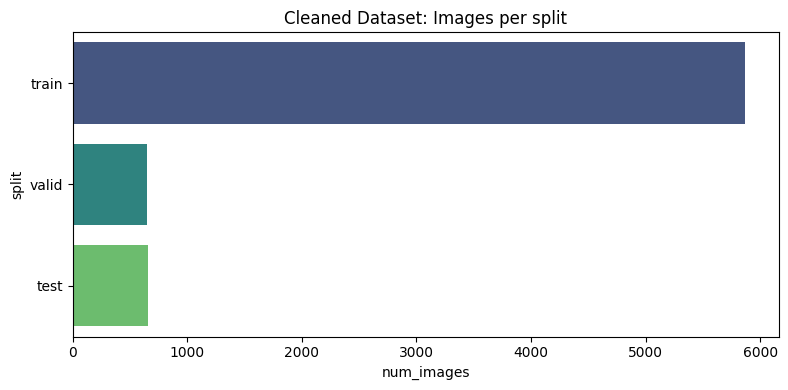

C:\Users\User\AppData\Local\Temp\ipykernel_20368\1064552285.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cleaned_class_counts_df, x='count', y='class_name', palette='Set2')


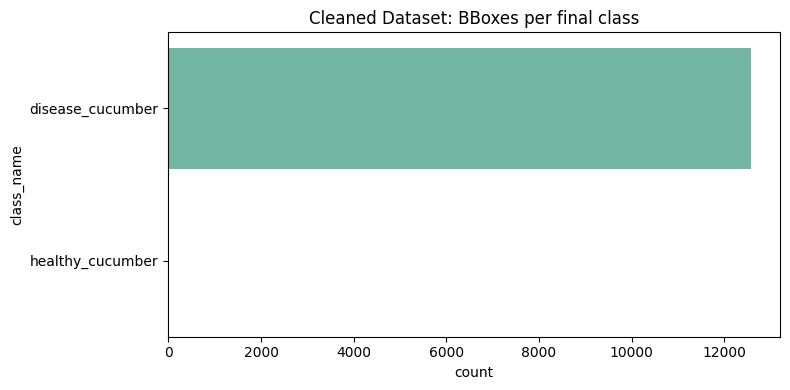

In [15]:
CLEANED_PLOTS_PATH = Path('data/output/cucumber_v1_cleaned')
CLEANED_PLOTS_PATH.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 4))
sns.barplot(data=cleaned_stats_df, x='num_images', y='split', palette='viridis')
plt.title('Cleaned Dataset: Images per split')
plt.tight_layout()
plt.savefig(CLEANED_PLOTS_PATH / 'cleaned_images_per_split.png', dpi=300)
display(plt.gcf())
plt.close()

plt.figure(figsize=(8, 4))
sns.barplot(data=cleaned_class_counts_df, x='count', y='class_name', palette='Set2')
plt.title('Cleaned Dataset: BBoxes per final class')
plt.tight_layout()
plt.savefig(CLEANED_PLOTS_PATH / 'cleaned_bboxes_per_class.png', dpi=300)
display(plt.gcf())
plt.close()

In [16]:
cleaned_stats_df.to_csv(CLEANED_PLOTS_PATH / 'cleaned_split_stats.csv', index=False)
cleaned_class_counts_df.to_csv(CLEANED_PLOTS_PATH / 'cleaned_bbox_stats.csv', index=False)

print(f'Saved cleaned_split_stats.csv to {CLEANED_PLOTS_PATH.resolve()}')
print(f'Saved cleaned_bbox_stats.csv to {CLEANED_PLOTS_PATH.resolve()}')

Saved cleaned_split_stats.csv to C:\Users\User\Desktop\vegvision-yolo\notebooks\data\output\cucumber_v1_cleaned
Saved cleaned_bbox_stats.csv to C:\Users\User\Desktop\vegvision-yolo\notebooks\data\output\cucumber_v1_cleaned
